<a href="https://colab.research.google.com/github/KurniaYufi/sentiment-analysis-kematian-ali-khamenei/blob/main/data-preprocessing/article-preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Merge & Preprocessing Article News**

Notebook ini berfungsi untuk menggabungkan dataset dari berbagai sumber berita (Detik, Kompas, Tribun, Antara, CNN) menjadi satu kesatuan, serta melakukan pembersihan teks secara menyeluruh guna menyiapkan data untuk analisis sentimen.[cite: 2]

| # | Analisis | Deskripsi |
|:---:|:---|:---|
| 1 | **Konfigurasi & Setup** | Penentuan daftar file CSV input dan nama file output hasil penggabungan.[cite: 2] |
| 2 | **Data Loading** | Memuat file satu per satu dan menghapus baris dengan konten kosong atau hanya spasi.[cite: 2] |
| 3 | **Source Labeling** | Menambahkan kolom `News` secara otomatis berdasarkan nama file asal sumber berita.[cite: 2] |
| 4 | **Data Merging** | Menggabungkan seluruh dataframe menjadi satu file tunggal (`merged-articles.csv`).[cite: 2] |
| 5 | **Standardisasi Teks** | Menyeragamkan variasi penulisan nama tokoh (contoh: *khamene* menjadi *khamenei*).[cite: 2] |
| 6 | **Text Cleaning** | Menghapus URL, mention, angka, simbol, serta spasi berlebih pada teks berita.[cite: 2] |
| 7 | **Stopword Removal** | Menghapus kata umum bahasa Indonesia dan kata *boilerplate* jurnalistik (seperti: *dilansir*, *dikutip*).[cite: 2] |
| 8 | **Stemming (Sastrawi)** | Mengubah kata berimbuhan menjadi kata dasar untuk menormalkan struktur bahasa.[cite: 2] |
| 9 | **Sentiment Scoring** | Menerjemahkan teks ke Bahasa Inggris dan menghitung skor polaritas menggunakan *TextBlob*.[cite: 2] |
| 10 | **Visualisasi Insight** | Pembuatan grafik distribusi sentimen dan *Word Cloud* untuk memetakan kata-kata dominan.[cite: 2] |

---

## **(1) Konfigurasi**
Sesuaikan `csv_files` dan `output_file` sesuai kebutuhan.

In [ ]:
import pandas as pd
import os

In [ ]:
csv_files = [
    "detik-content-scraping.csv",
    "kompas-content-scraping.csv",
    "tribun-content-scraping.csv",
    "antara-content-scraping.csv",
    "cnn-content-scraping.csv"
]

output_file = "merged-articles.csv"   # nama file output
add_source_column = True              # Tambahkan kembali variabel ini agar kolom 'News' ditambahkan

## **(2) Load & Preview Setiap File**

In [ ]:
dfs = []
source_map = {
    "detik-content-scraping": "Detik",
    "kompas-content-scraping": "Kompas",
    "tribun-content-scraping": "Tribun",
    "antara-content-scraping": "Antara",
    "cnn-content-scraping": "CNN"
}

for filepath in csv_files:
    if not os.path.exists(filepath):
        print(f"[WARNING] File tidak ditemukan: {filepath} — dilewati.")
        continue

    df = pd.read_csv(filepath)

    # Hapus baris dengan konten kosong atau hanya spasi
    original_rows = len(df)
    df['content'] = df['content'].astype(str).str.strip()
    df = df[df['content'].replace('nan', '').str.len() > 0]
    if len(df) < original_rows:
        print(f"[INFO] {original_rows - len(df)} baris dengan konten kosong dihapus dari {filepath}")

    if add_source_column:
        # Ambil nama file tanpa ekstensi
        filename_base = os.path.splitext(os.path.basename(filepath))[0]
        # Dapatkan nama sumber dari mapping
        source_label = source_map.get(filename_base, "Unknown Source")
        df.insert(0, "News", source_label)

    dfs.append(df)
    print(f"✅ {filepath:45s} → {len(df):,} baris, {df.shape[1]} kolom")

print(f"\nTotal file berhasil dimuat: {len(dfs)}")

[INFO] 4 baris dengan konten kosong dihapus dari detik-content-scraping.csv
✅ detik-content-scraping.csv                    → 96 baris, 4 kolom
[INFO] 4 baris dengan konten kosong dihapus dari kompas-content-scraping.csv
✅ kompas-content-scraping.csv                   → 96 baris, 4 kolom
✅ tribun-content-scraping.csv                   → 100 baris, 4 kolom
✅ antara-content-scraping.csv                   → 100 baris, 4 kolom
✅ cnn-content-scraping.csv                      → 99 baris, 4 kolom

Total file berhasil dimuat: 5


## **(3) Merge Data**

In [ ]:
if not dfs:
    raise ValueError("Tidak ada file yang berhasil dimuat. Periksa path file.")

merged = pd.concat(dfs, ignore_index=True)

merged.to_csv(output_file, index=False)

print(f"✅ File berhasil disimpan: {output_file}")
print(f"   Total baris  : {len(merged):,}")
print(f"   Total kolom  : {merged.shape[1]}")

✅ File berhasil disimpan: merged-articles.csv
   Total baris  : 491
   Total kolom  : 4


In [ ]:
print("=== 5 Baris Pertama ===")
display(merged.head())

print("\n=== Info Kolom ===")
merged.info()

if add_source_column:
    print("\n=== Distribusi per Sumber (Kolom 'News') ===")
    display(merged["News"].value_counts().rename_axis("News").reset_index(name="jumlah_artikel"))

=== 5 Baris Pertama ===


,News,url,title,content
0,Detik,https://news.detik.com/berita/d-8392835/puan-b...,Puan Berduka Ali Khamenei Gugur Diserang AS-Is...,Ketua DPR RI Puan Maharani menyampaikan dukaci...
1,Detik,https://news.detik.com/internasional/d-8392814...,Trump Beri Sinyal Perang Lawan Iran Akan Selesai,Presiden Amerika Serikat (AS) Donald Trump men...
2,Detik,https://www.detik.com/bali/berita/d-8392847/pe...,Peringatan Keras Iran ke Kapal Tanker yang Nek...,Ilyas Fadilah - detikBali\n\nHarga minyak duni...
3,Detik,https://finance.detik.com/energi/d-8392622/ira...,Iran Beri Peringatan Keras Kapal Tanker yang M...,"Juru Bicara Kementerian Luar Negeri Iran, Esma..."
4,Detik,https://finance.detik.com/energi/d-8392622/ira...,Iran Beri Peringatan Keras Kapal Tanker yang M...,"Juru Bicara Kementerian Luar Negeri Iran, Esma..."



=== Info Kolom ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   News     491 non-null    object
 1   url      491 non-null    object
 2   title    491 non-null    object
 3   content  491 non-null    object
dtypes: object(4)
memory usage: 15.5+ KB

=== Distribusi per Sumber (Kolom 'News') ===


,News,jumlah_artikel
0,Tribun,100
1,Antara,100
2,CNN,99
3,Detik,96
4,Kompas,96


# **Preproccessing Article News**

**(1) Instalasi Library**

Bagian ini berisi instalasi semua library Python yang dibutuhkan untuk preprocessing teks dan analisis sentimen. Karena `polyglot` membutuhkan library sistem `libicu-dev`, kita perlu menginstalnya terlebih dahulu.

In [ ]:
# Instalasi library NLP yang dibutuhkan
!pip install langdetect
!pip install deep-translator
!pip install Sastrawi
!pip install stanza
!pip install nltk
!pip install wordcloud


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 23.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=a13b2bfd471e8c2080464ab839f3e939407b073aefd4bffb5c539b3497a667fa
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


**(2) Impor Library**

Bagian ini mengimpor semua modul dan fungsi yang diperlukan dari library yang telah diinstal. Import dikelompokkan berdasarkan fungsinya.

In [ ]:
# Standard Library
import io
import string
import re
import time
from collections import defaultdict, Counter

# Data Handling
import pandas as pd
import numpy as np

# (Opsional)
from google.colab import files

# NLP - NLTK
import nltk
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

# NLP - Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# NLP - Stanza
import stanza

# NLP - Language Detection
from langdetect import detect as langdetect_detect, LangDetectException

# Sentiment Analysis
from textblob import TextBlob
from deep_translator import GoogleTranslator

# Visualization
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [ ]:
# Download NLTK data (if not already downloaded)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

**(3) Data Preprocessing**

Bagian ini membersihkan dan mempersiapkan teks dari artikel yang discrape untuk analisis lebih lanjut. Langkah-langkah dilakukan secara berurutan:
1. **Standarisasi Nama**: Menyeragamkan variasi penulisan nama sebelum cleaning (contoh: `khamene` → `khamenei`).
2. **`clean_text`**: Menghilangkan URL, mention, angka, tanda baca, dan spasi berlebih → menghasilkan kolom `text_cleaned`.
3. **`tokenize_text`**: Memecah `text_cleaned` menjadi list token → menghasilkan kolom `tokens`.
4. **`remove_stopwords`**: Menghapus stopwords bahasa Indonesia (NLTK) dan custom stopwords dari `tokens` → menghasilkan kolom `tokens_no_stop` dan `text_no_stopwords`.
5. **`stem_text`**: Melakukan stemming pada `tokens_no_stop` menggunakan `Sastrawi` → menghasilkan kolom `tokens_stemmed` dan `text_final`.
6. **Deteksi Bahasa**: Menggunakan `langdetect` untuk mendeteksi bahasa teks.

> **Catatan**: Kolom `text_no_stopwords` (sebelum stemming) digunakan untuk POS Tagging dan NER, karena stemming dapat mengubah bentuk kata dan mengurangi akurasi pengenalan entitas.

Library yang digunakan: `re`, `string`, `nltk`, `Sastrawi`, `langdetect`.


In [ ]:
df_article = pd.read_csv('merged-articles.csv')
print("DataFrame 'df_article' berhasil dimuat dengan data dari 'merged-articles.csv'.")
print(f"Total baris: {len(df_article)}")
print(f"Total kolom: {df_article.shape[1]}")
print("Tampilan 5 baris pertama:")
display(df_article.head())

DataFrame 'df_article' berhasil dimuat dengan data dari 'merged-articles.csv'.
Total baris: 491
Total kolom: 4
Tampilan 5 baris pertama:


,News,url,title,content
0,Detik,https://news.detik.com/berita/d-8392835/puan-b...,Puan Berduka Ali Khamenei Gugur Diserang AS-Is...,Ketua DPR RI Puan Maharani menyampaikan dukaci...
1,Detik,https://news.detik.com/internasional/d-8392814...,Trump Beri Sinyal Perang Lawan Iran Akan Selesai,Presiden Amerika Serikat (AS) Donald Trump men...
2,Detik,https://www.detik.com/bali/berita/d-8392847/pe...,Peringatan Keras Iran ke Kapal Tanker yang Nek...,Ilyas Fadilah - detikBali\n\nHarga minyak duni...
3,Detik,https://finance.detik.com/energi/d-8392622/ira...,Iran Beri Peringatan Keras Kapal Tanker yang M...,"Juru Bicara Kementerian Luar Negeri Iran, Esma..."
4,Detik,https://finance.detik.com/energi/d-8392622/ira...,Iran Beri Peringatan Keras Kapal Tanker yang M...,"Juru Bicara Kementerian Luar Negeri Iran, Esma..."


In [ ]:
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

def clean_text(text):
    if not isinstance(text, str): # Handle non-string input, e.g., None
        return ""
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'@\w+', '', text) # Remove mentions
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    return text

def tokenize_text(text):
    if not isinstance(text, str): # Handle non-string input
        return []
    return word_tokenize(text)

# Get Indonesian stopwords
list_stopwords = nltk.corpus.stopwords.words('indonesian')

# Stopwords custom
custom_stopwords = [
    # Nama media & artefak scraping
    "detik", "detiknews", "kompas", "kompascom", "tribun", "tribunx",
    "antara", "cnn", "cnnindonesia", "reuters", "afp", "irib",
    "baca", "com", "app", "store", "play", "serambine", "serambinew", "serambinewscom", "serambinews",
    "tribunjambicom", "tribunjatimcom", "tribuntrendscom", "abc news", "cbs news",
    "banjarmasinpostcoid", "wartakotalivecom", "fox news",
    # Kata boilerplate jurnalistik
    "dikutip", "dilansir", "dilaporkan", "mengatakan", "menyatakan",
    "menyebut", "kata", "menegaskan", "menurut", "laporan", "video",
    "kantor", "pernyataan", "berita",
    # Kata temporal generik
    "senin", "selasa", "rabu", "kamis", "jumat", "sabtu", "minggu",
    # Kata deskriptif terlalu umum
    "seorang", "sebuah", "sejumlah", "tersebut", "bahwa",
]
list_stopwords = list(set(list_stopwords + custom_stopwords))

def remove_stopwords(tokens, stopwords_list):
    return [word for word in tokens if word not in stopwords_list and word.strip() != '']

def stem_text(tokens):
    return [stemmer.stem(word) for word in tokens]

In [ ]:
# Standarisasi variasi penulisan nama sebelum cleaning
df_article['content'] = df_article['content'].str.replace(
    r'\bkhamene\b', 'khamenei', regex=True, case=False
)

# 1. Cleaning teks
df_article['text_cleaned'] = df_article['content'].fillna('').apply(clean_text)

# 2. Tokenisasi dari text_cleaned
df_article['tokens'] = df_article['text_cleaned'].apply(tokenize_text)

# 3. Hapus stopwords dari tokens → simpan sebagai list dan string
df_article['tokens_no_stop'] = df_article['tokens'].apply(lambda x: remove_stopwords(x, list_stopwords))
df_article['text_no_stopwords'] = df_article['tokens_no_stop'].apply(lambda x: ' '.join(x))

# 4. Stemming dari tokens_no_stop → simpan sebagai list dan string
df_article['tokens_stemmed'] = df_article['tokens_no_stop'].apply(stem_text)
df_article['text_final'] = df_article['tokens_stemmed'].apply(lambda x: ' '.join(x))

print("DataFrame setelah preprocessing:")
print(df_article[['content', 'text_cleaned', 'tokens', 'tokens_no_stop', 'text_no_stopwords', 'tokens_stemmed', 'text_final']].head())

# Deteksi bahasa pada konten asli menggunakan langdetect
print("\nDeteksi Bahasa pada Konten Asli:")
for index, row in df_article.head(5).iterrows():
    try:
        content = row['content'] if pd.notna(row['content']) else ''
        lang = langdetect_detect(content)
        print(f"Row {index}: Language Detected: {lang}")
    except LangDetectException as e:
        print(f"Row {index}: Language detection failed - {e}")


DataFrame setelah preprocessing:
                                             content  \
0  Ketua DPR RI Puan Maharani menyampaikan dukaci...   
1  Presiden Amerika Serikat (AS) Donald Trump men...   
2  Ilyas Fadilah - detikBali\n\nHarga minyak duni...   
3  Juru Bicara Kementerian Luar Negeri Iran, Esma...   
4  Juru Bicara Kementerian Luar Negeri Iran, Esma...   

                                        text_cleaned  \
0  ketua dpr ri puan maharani menyampaikan dukaci...   
1  presiden amerika serikat as donald trump menga...   
2  ilyas fadilah detikbali harga minyak dunia mel...   
3  juru bicara kementerian luar negeri iran esmai...   
4  juru bicara kementerian luar negeri iran esmai...   

                                              tokens  \
0  [ketua, dpr, ri, puan, maharani, menyampaikan,...   
1  [presiden, amerika, serikat, as, donald, trump...   
2  [ilyas, fadilah, detikbali, harga, minyak, dun...   
3  [juru, bicara, kementerian, luar, negeri, iran...   
4  [juru, bic

**(4) Analisis Sentimen**

Bagian ini menganalisis sentimen dari teks artikel. Karena `TextBlob` hanya mendukung bahasa Inggris, teks bahasa Indonesia akan diterjemahkan terlebih dahulu ke bahasa Inggris menggunakan `GoogleTranslator`, kemudian dianalisis polaritasnya. Teks panjang juga ditangani dengan memecahnya menjadi beberapa bagian untuk menghindari batasan API.

Library yang digunakan: `TextBlob`, `deep_translator`.

In [ ]:
def analyze_long_text_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return pd.Series([None, None])

    # If text is short, directly process
    if len(text) < 4500:
        try:
            translated_text = GoogleTranslator(source='id', target='en').translate(text)
            blob = TextBlob(translated_text)
            return pd.Series([blob.sentiment.polarity, blob.sentiment.subjectivity])
        except Exception as e:
            print(f"Error processing short text: {e}")
            return pd.Series([None, None])

    # If text is long, chunk it
    else:
        try:
            max_chunk_size = 4500
            chunks = [text[i:i+max_chunk_size] for i in range(0, len(text), max_chunk_size)]

            translated_chunks = []
            for i, chunk in enumerate(chunks):
                # Add a small delay to avoid hitting API rate limits
                if i > 0: # Only sleep for subsequent chunks
                    time.sleep(0.5)
                translated_chunks.append(
                    GoogleTranslator(source='id', target='en').translate(chunk)
                )

            # Combine all translated chunks
            full_translated_text = ' '.join(translated_chunks)

            # Analyze sentiment of the full translated text
            blob = TextBlob(full_translated_text)
            return pd.Series([blob.sentiment.polarity, blob.sentiment.subjectivity])

        except Exception as e:
            print(f"Error processing long text: {e}")
            return pd.Series([None, None])

def get_sentiment_label_from_polarity(polarity):
    if polarity is None:
        return 'Undefined'
    elif polarity > 0.05:
        return 'Positive'
    elif polarity < -0.05:
        return 'Negative'
    else:
        return 'Netral'

# Apply the sentiment analysis function to the 'text_final' column
df_article[['polarity', 'subjectivity']] = df_article['text_final'].apply(analyze_long_text_sentiment)

# Fill any NaN polarity values with 0 before labeling
df_article['polarity'].fillna(0, inplace=True)

# Create sentiment labels
df_article['sentiment_label'] = df_article['polarity'].apply(get_sentiment_label_from_polarity)

print("\nDataFrame dengan hasil sentimen:")
print(df_article[['content', 'text_final', 'polarity', 'subjectivity', 'sentiment_label']].head())


DataFrame dengan hasil sentimen:
                                             content  \
0  Ketua DPR RI Puan Maharani menyampaikan dukaci...   
1  Presiden Amerika Serikat (AS) Donald Trump men...   
2  Ilyas Fadilah - detikBali\n\nHarga minyak duni...   
3  Juru Bicara Kementerian Luar Negeri Iran, Esma...   
4  Juru Bicara Kementerian Luar Negeri Iran, Esma...   

                                          text_final  polarity  subjectivity  \
0  ketua dpr ri puan maharani dukacita masyarakat...  0.007451      0.210196   
1  presiden amerika serikat as donald trump peran...  0.149333      0.364000   
2  ilyas fadilah detikbali harga minyak dunia lon...  0.029412      0.452941   
3  juru bicara menteri negeri iran esmail baghaei... -0.031579      0.438158   
4  juru bicara menteri negeri iran esmail baghaei... -0.031579      0.438158   

  sentiment_label  
0          Netral  
1        Positive  
2          Netral  
3          Netral  
4          Netral  


/tmp/ipykernel_4375/502083443.py:55: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_article['polarity'].fillna(0, inplace=True)



=== Distribusi Sentimen ===


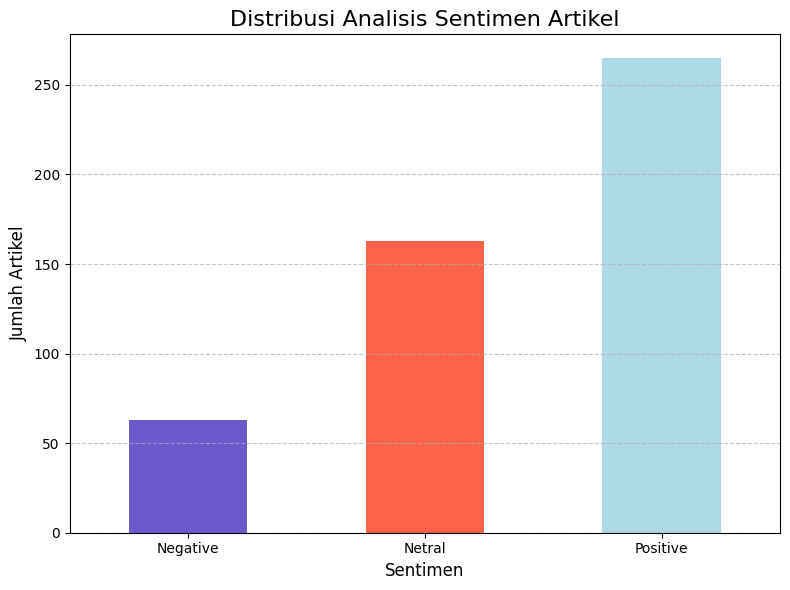

,Jumlah Artikel
sentiment_label,
Negative,63
Netral,163
Positive,265


In [ ]:
print("\n=== Distribusi Sentimen ===")
sentiment_counts = df_article['sentiment_label'].value_counts().sort_index()

plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color=['#6A5ACD', '#FF6347', '#ADD8E6'])
plt.title('Distribusi Analisis Sentimen Artikel', fontsize=16)
plt.xlabel('Sentimen', fontsize=12)
plt.ylabel('Jumlah Artikel', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

display(sentiment_counts.to_frame(name='Jumlah Artikel'))

**(5) Visualisasi (Word Cloud)**

Bagian ini membuat visualisasi Word Cloud untuk kata-kata yang paling sering muncul dalam artikel dengan sentimen Positif dan Negatif. Ini membantu dalam memahami topik yang terkait dengan masing-masing sentimen.

Library yang digunakan: `matplotlib.pyplot`, `wordcloud`.


Jumlah artikel Positif: 265
Jumlah artikel Negatif: 63


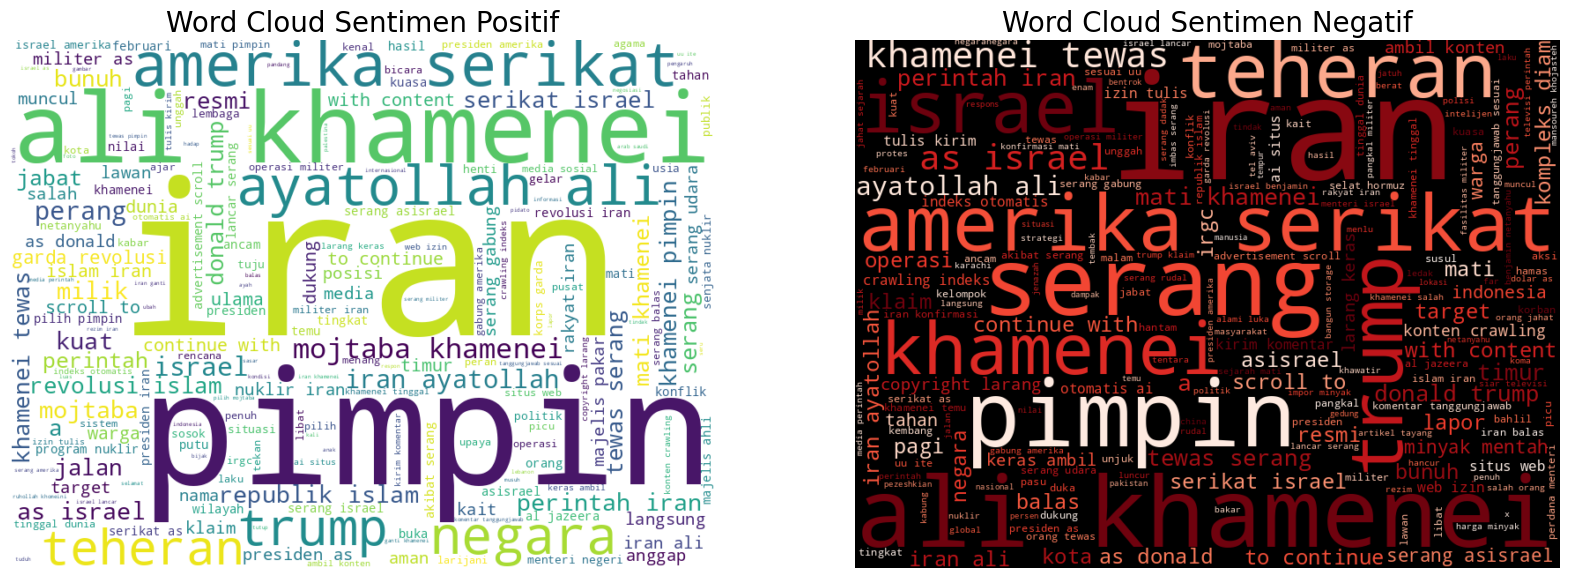

In [ ]:
positive_articles_df = df_article[df_article['sentiment_label'] == 'Positive']
negative_articles_df = df_article[df_article['sentiment_label'] == 'Negative']

print(f"\nJumlah artikel Positif: {len(positive_articles_df)}")
print(f"Jumlah artikel Negatif: {len(negative_articles_df)}")

positive_text = ' '.join(positive_articles_df['text_final'])
negative_text = ' '.join(negative_articles_df['text_final'])

plt.figure(figsize=(20, 10))

# Word Cloud Positif
if positive_text:
    plt.subplot(1, 2, 1)
    wordcloud_positive = WordCloud(
        stopwords=list_stopwords,
        width=800,
        height=600,
        background_color='white',
        colormap='viridis'
    ).generate(positive_text)
    plt.imshow(wordcloud_positive, interpolation='bilinear')
    plt.title('Word Cloud Sentimen Positif', fontsize=20)
    plt.axis('off')
else:
    print("Tidak ada teks positif untuk Word Cloud.")

# Word Cloud Negatif
if negative_text:
    plt.subplot(1, 2, 2)
    wordcloud_negative = WordCloud(
        stopwords=list_stopwords,
        width=800,
        height=600,
        background_color='black',
        colormap='Reds'
    ).generate(negative_text)
    plt.imshow(wordcloud_negative, interpolation='bilinear')
    plt.title('Word Cloud Sentimen Negatif', fontsize=20)
    plt.axis('off')
else:
    print("Tidak ada teks negatif untuk Word Cloud.")

plt.show()

**(6) Ekspor Hasil**

Bagian ini menyimpan DataFrame akhir yang berisi semua data, hasil preprocessing, dan sentimen ke dalam file CSV.

In [ ]:
df_article.to_csv(r'article-preprocess.csv', index=False)
print("Hasil analisis disimpan ke 'article-preprocess.csv'")

Hasil analisis disimpan ke 'article-preprocess.csv'
